# 01b - Figuras finales de la EDA

Este notebook se utiliza para generar las versiones definitivas de las figuras de la EDA (ver `notebooks/01a_eda_o3.ipynb`) consideradas más relevantes para la memoria (y para la presentación final).

También, de esta manera, se consolidan visualmente los hallazgos principales obtenidos durante la EDA.

Las figuras exploratorias previamente obtenidas se guardaron en `reports/figures/generated/`, mientras que estas figuras finales se guardarán en:

`reports/figures/final/`

## Figuras generadas

Este notebook permite generar las siguientes figuras definitivas para la serie temporal de ozono troposférico (O3):

1. `fig_eda_01_temporal_overview.png`: vista temporal general, media móvil y partición cronológica.
2. `fig_eda_02_missingness_year_month.png`: valores ausentes por año y mes.
3. `fig_eda_03_o3_distribution.png`: distribución de la concentración horaria de O3.
4. `fig_eda_04_seasonality_boxplots.png`: estacionalidad mensual, semanal y horaria.
5. `fig_eda_05_month_hour_p90_heatmap.png`: percentil 90 de O3 por mes y hora.
6. `fig_eda_06_acf_lags.png`: autocorrelación de la concentración de O3 para retardos de hasta 168 horas.
7. `fig_eda_07_diff24_correlograms.png`: ACF y PACF de la serie diferenciada respecto al día anterior (`lag_24`).
8. `fig_eda_08_interannual_overlay.png`: comparación interanual de los perfiles anuales suavizados de O3.

Las figuras de diagnóstico de residuos de la regla de persistencia diaria se trasladan a la fase de modelado, ya que analizan el comportamiento de un modelo concreto y no la serie en sí misma.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy import stats
from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

In [2]:
def find_project_root(start: Path | None = None) -> Path:
    """Busca la raíz del proyecto partiendo del directorio actual.

    Esta función evita depender de rutas absolutas locales. Así, el notebook puede
    ejecutarse aunque el repositorio esté guardado en otra carpeta o se abra desde
    un directorio diferente dentro del proyecto.
    """
    start = Path.cwd() if start is None else start

    for candidate in [start, *start.parents]:
        if (candidate / "data").exists() and (candidate / "src").exists():
            return candidate

    raise FileNotFoundError("No se ha podido localizar la raíz del proyecto.")

# Se utiliza la función definida para localizar automáticamente el directorio raíz del repositorio.
PROJECT_ROOT = find_project_root()

# Conjunto de datos procesado que se generará a partir del conjunto de datos bruto.
PROCESSED_DATA_PATH = PROJECT_ROOT / "data" / "processed" / "o3_hourly.parquet"

# Directorios donde se guardarán las tablas y figuras generadas durante la EDA.
TABLES_DIR = PROJECT_ROOT / "reports" / "tables"
FIGURES_FINAL_DIR = PROJECT_ROOT / "reports" / "figures" / "final"

# Se comprueba, adicionalmente, que los directorios de salida existan.
TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_FINAL_DIR.mkdir(parents=True, exist_ok=True)

print(f"Raíz del proyecto: {PROJECT_ROOT}")
print(f"Dataset horario base: {PROCESSED_DATA_PATH}")
print(f"Carpeta figuras finales: {FIGURES_FINAL_DIR}")

Raíz del proyecto: c:\trabajo_github
Dataset horario base: c:\trabajo_github\data\processed\o3_hourly.parquet
Carpeta figuras finales: c:\trabajo_github\reports\figures\final


In [3]:
# La EDA parte del conjunto de datos generado por el notebook 00.
# Si este archivo no existe, para obtenerlo, primero deberá ejecutarse notebooks/00_data_preparation_o3.ipynb.
if not PROCESSED_DATA_PATH.exists():
    raise FileNotFoundError(
        "No se ha encontrado data/processed/o3_hourly.parquet. "
        "Ejecuta primero notebooks/00_data_preparation_o3.ipynb."
    )

hourly_df = pd.read_parquet(PROCESSED_DATA_PATH)

# Se asegura que la columna temporal se halle en formato datetime.
hourly_df["timestamp"] = pd.to_datetime(hourly_df["timestamp"])

print(f"Filas: {hourly_df.shape[0]:,}")
print(f"Columnas: {hourly_df.shape[1]:,}")

display(hourly_df.head())
display(hourly_df.tail())

Filas: 52,608
Columnas: 16


,timestamp,o3,station_code,station_name,pollutant_code,pollutant,units,station_type,urban_area,ine_code,municipality,county_code,county_name,altitude,latitude,longitude
0,2020-01-01 00:00:00,22.0,8019043,Barcelona (Eixample),14,O3,µg/m3,traffic,urban,8019,Barcelona,13,Barcelonès,26,41.385315,2.1538
1,2020-01-01 01:00:00,19.0,8019043,Barcelona (Eixample),14,O3,µg/m3,traffic,urban,8019,Barcelona,13,Barcelonès,26,41.385315,2.1538
2,2020-01-01 02:00:00,19.0,8019043,Barcelona (Eixample),14,O3,µg/m3,traffic,urban,8019,Barcelona,13,Barcelonès,26,41.385315,2.1538
3,2020-01-01 03:00:00,6.0,8019043,Barcelona (Eixample),14,O3,µg/m3,traffic,urban,8019,Barcelona,13,Barcelonès,26,41.385315,2.1538
4,2020-01-01 04:00:00,8.0,8019043,Barcelona (Eixample),14,O3,µg/m3,traffic,urban,8019,Barcelona,13,Barcelonès,26,41.385315,2.1538


,timestamp,o3,station_code,station_name,pollutant_code,pollutant,units,station_type,urban_area,ine_code,municipality,county_code,county_name,altitude,latitude,longitude
52603,2025-12-31 19:00:00,25.0,8019043,Barcelona (Eixample),14,O3,µg/m3,traffic,urban,8019,Barcelona,13,Barcelonès,26,41.385315,2.1538
52604,2025-12-31 20:00:00,32.0,8019043,Barcelona (Eixample),14,O3,µg/m3,traffic,urban,8019,Barcelona,13,Barcelonès,26,41.385315,2.1538
52605,2025-12-31 21:00:00,36.0,8019043,Barcelona (Eixample),14,O3,µg/m3,traffic,urban,8019,Barcelona,13,Barcelonès,26,41.385315,2.1538
52606,2025-12-31 22:00:00,39.0,8019043,Barcelona (Eixample),14,O3,µg/m3,traffic,urban,8019,Barcelona,13,Barcelonès,26,41.385315,2.1538
52607,2025-12-31 23:00:00,42.0,8019043,Barcelona (Eixample),14,O3,µg/m3,traffic,urban,8019,Barcelona,13,Barcelonès,26,41.385315,2.1538


In [4]:
# Comprobación básica del esquema de datos que se espera tenga el conjunto de datos.
# La validación exhaustiva del mismo se efectúa en notebooks/00_data_preparation_o3.ipynb.
required_columns = [
    "timestamp",
    "o3",
    "station_code",
    "station_name",
    "pollutant",
    "units",
]

missing_columns = [
    column for column in required_columns
    if column not in hourly_df.columns
]

if missing_columns:
    raise ValueError(f"Faltan las siguientes columnas esperadas en el conjunto de datos procesado: {missing_columns}")

print(f"Inicio de la serie: {hourly_df['timestamp'].min()}")
print(f"Fin de la serie: {hourly_df['timestamp'].max()}")

display(hourly_df[["timestamp", "o3", "station_name", "pollutant", "units"]].head())

Inicio de la serie: 2020-01-01 00:00:00
Fin de la serie: 2025-12-31 23:00:00


,timestamp,o3,station_name,pollutant,units
0,2020-01-01 00:00:00,22.0,Barcelona (Eixample),O3,µg/m3
1,2020-01-01 01:00:00,19.0,Barcelona (Eixample),O3,µg/m3
2,2020-01-01 02:00:00,19.0,Barcelona (Eixample),O3,µg/m3
3,2020-01-01 03:00:00,6.0,Barcelona (Eixample),O3,µg/m3
4,2020-01-01 04:00:00,8.0,Barcelona (Eixample),O3,µg/m3


In [5]:
# Configuración común para las figuras finales.
# Se define un estilo sencillo y homogéneo en línea con el ya utilizado,
# que se estima adecuado para la memoria y la presentación.
plt.rcParams.update(
    {
        "font.size": 10,
        "axes.titlesize": 12,
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 9,
        "figure.titlesize": 13,
    }
)

MONTH_LABELS = {
    1: "Ene",
    2: "Feb",
    3: "Mar",
    4: "Abr",
    5: "May",
    6: "Jun",
    7: "Jul",
    8: "Ago",
    9: "Sep",
    10: "Oct",
    11: "Nov",
    12: "Dic",
}

WEEKDAY_LABELS = [
    "Lunes",
    "Martes",
    "Miércoles",
    "Jueves",
    "Viernes",
    "Sábado",
    "Domingo",
]

BLOCK_BOUNDARIES = {
    "Calibración": pd.Timestamp("2023-01-01"),
    "Validación": pd.Timestamp("2024-01-01"),
    "Prueba": pd.Timestamp("2025-01-01"),
}

MODELING_END = pd.Timestamp("2024-12-31 23:00:00")

def save_final_figure(fig: plt.Figure, filename: str) -> Path:
    """Guarda una figura final en reports/figures/final."""
    output_path = FIGURES_FINAL_DIR / filename
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    print(f"Figura guardada en: {output_path}")
    return output_path

def add_panel_label(ax: plt.Axes, label: str) -> None:
    """Añade una etiqueta de panel dentro de una figura compuesta."""
    ax.text(
        0.01,
        0.98,
        label,
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontweight="bold",
        fontsize=11,
    )

In [6]:
# Se añaden variables temporales para facilitar los análisis.
# Se definen los siguientes dos subconjuntos:
# a) eda_all_df / observed_all_df: periodo completo 2020-2025, dirigido a la auditoría y el particionado en bloques del dataset.
# b) eda_modeling_df / observed_modeling_df: periodo 2020-2024, útil para los análisis que orientarán el modelado.

eda_all_df = hourly_df.copy()

eda_all_df["timestamp"] = pd.to_datetime(eda_all_df["timestamp"])
eda_all_df["date"] = eda_all_df["timestamp"].dt.floor("D")
eda_all_df["year"] = eda_all_df["timestamp"].dt.year
eda_all_df["month"] = eda_all_df["timestamp"].dt.month
eda_all_df["hour"] = eda_all_df["timestamp"].dt.hour
eda_all_df["day_of_week"] = eda_all_df["timestamp"].dt.dayofweek

observed_all_df = eda_all_df.dropna(subset=["o3"]).copy()

# Periodo previo al conjunto de prueba.
eda_modeling_df = eda_all_df[
    eda_all_df["timestamp"] <= MODELING_END
].copy()

observed_modeling_df = eda_modeling_df.dropna(subset=["o3"]).copy()

eda_df = eda_all_df
observed_df = observed_all_df

print(
    "Periodo completo:",
    eda_all_df["timestamp"].min(),
    "→",
    eda_all_df["timestamp"].max(),
)

print(
    "Periodo previo al conjunto de prueba:",
    eda_modeling_df["timestamp"].min(),
    "→",
    eda_modeling_df["timestamp"].max(),
)

print(f"Observaciones completas no ausentes: {len(observed_all_df):,}")
print(f"Observaciones 2020-2024 no ausentes: {len(observed_modeling_df):,}")

assert eda_modeling_df["timestamp"].max() <= MODELING_END
assert observed_modeling_df["timestamp"].max() <= MODELING_END

Periodo completo: 2020-01-01 00:00:00 → 2025-12-31 23:00:00
Periodo previo al conjunto de prueba: 2020-01-01 00:00:00 → 2024-12-31 23:00:00
Observaciones completas no ausentes: 50,942
Observaciones 2020-2024 no ausentes: 42,561


## Figura 1 - Vista temporal general, media móvil y partición cronológica de la serie

Esta figura combina la serie horaria original del ozono troposférico (O3), la media diaria, la media móvil de 30 días y las fronteras de la partición cronológica.

Su función es presentar visualmente a los lectores la variabilidad real de la serie y justificar el uso de una partición temporal estricta.

Figura guardada en: c:\trabajo_github\reports\figures\final\fig_eda_01_temporal_overview.png


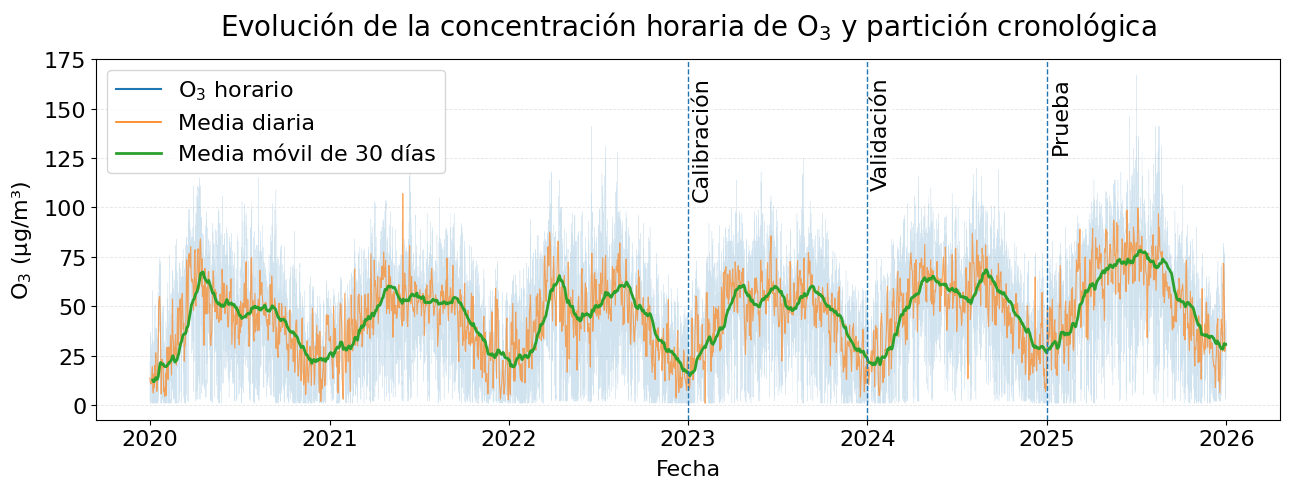

In [52]:
from matplotlib.lines import Line2D

temporal_df = eda_df[["timestamp", "date", "o3"]].copy()

daily_o3 = (
    temporal_df
    .dropna(subset=["o3"])
    .groupby("date")["o3"]
    .mean()
    .to_frame(name="daily_mean_o3")
    .sort_index()
)

daily_o3["rolling_30d_mean_o3"] = daily_o3["daily_mean_o3"].rolling(
    window=30,
    min_periods=7,
).mean()

fig, ax = plt.subplots(figsize=(13, 5))

# Se definen los colores para cada componente de la gráfica
hourly_color = "tab:blue"
daily_color = "tab:orange"
rolling_color = "tab:green"
boundary_color = "tab:blue"

# Se dibuja la serie horaria de O3 con cierta transparencia para que la media diaria
# y móvil también sean visibles y fáciles de interpretar.
ax.plot(
    temporal_df["timestamp"],
    temporal_df["o3"],
    linewidth=0.25,
    alpha=0.20,
    color=hourly_color,
)

# Se dibuja la media diaria de O3.
ax.plot(
    daily_o3.index,
    daily_o3["daily_mean_o3"],
    linewidth=0.8,
    alpha=0.65,
    color=daily_color,
)

# Se dibuja la media móvil
ax.plot(
    daily_o3.index,
    daily_o3["rolling_30d_mean_o3"],
    linewidth=2.0,
    color=rolling_color,
)

# Se añaden las fronteras verticales entre bloques cronológicos.
upper_y = ax.get_ylim()[1]

for label, boundary in BLOCK_BOUNDARIES.items():
    ax.axvline(
        boundary,
        linestyle="--",
        linewidth=1,
        color=boundary_color,
    )
    ax.text(
        boundary + pd.Timedelta(days=8),
        upper_y * .95,
        label,
        rotation=90,
        va="top",
        ha="left",
        fontsize=16,
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.75,
            pad=1.5,
        ),
    )

ax.set_title(
    r"Evolución de la concentración horaria de $\mathrm{O}_3$ y partición cronológica",
    fontsize=20, pad = 17
)
ax.set_xlabel("Fecha", fontsize=16, labelpad = 7)
ax.set_ylabel(r"$\mathrm{O}_3$ (µg/m³)", fontsize=16, labelpad = 7)

ax.tick_params(axis="both", labelsize=16)

ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.35)

# Se dibuja la leyenda de la gráfica
legend_handles = [
    Line2D([0], [0], color=hourly_color, linewidth=1.5, label=r"$\mathrm{O}_3$ horario"),
    Line2D([0], [0], color=daily_color, linewidth=1.2, label="Media diaria"),
    Line2D([0], [0], color=rolling_color, linewidth=2.0, label="Media móvil de 30 días"),
]

ax.legend(
    handles=legend_handles,
    loc="upper left",
    fontsize=16,
    title_fontsize=13
)

fig.tight_layout()

save_final_figure(fig, "fig_eda_01_temporal_overview.png")

plt.show()

## Figura 2 - Valores ausentes de la serie por año y mes

Este mapa de calor resume la distribución temporal de los valores ausentes de O3.

Su función es documentar los huecos en la serie y la decisión de no imputarlos indiscriminadamente, ya que, como se aprecia, en general la continuidad de las medidas es adecuada y no se desea introducir sesgos durante el entrenamiento o la evaluación.

,Ene,Feb,Mar,Abr,May,Jun,Jul,Ago,Sep,Oct,Nov,Dic
year,,,,,,,,,,,,
2020,0.54,0.72,0.81,1.53,0.27,0.69,0.81,0.27,0.42,0.94,8.19,0.94
2021,9.27,3.42,1.08,4.17,10.75,0.56,5.91,0.54,0.42,0.54,0.83,0.94
2022,0.27,0.30,0.81,13.33,10.22,2.08,0.54,0.54,7.08,0.54,16.39,1.34
2023,0.54,1.19,0.81,0.83,1.08,7.22,2.02,0.94,0.14,0.81,1.11,4.30
2024,17.20,0.57,0.40,4.72,2.42,12.22,4.30,0.67,1.25,1.08,1.67,0.81
2025,1.08,1.34,5.51,2.36,8.20,4.44,13.44,1.88,1.25,0.81,10.42,0.94


Figura guardada en: c:\trabajo_github\reports\figures\final\fig_eda_02_missingness_year_month.png


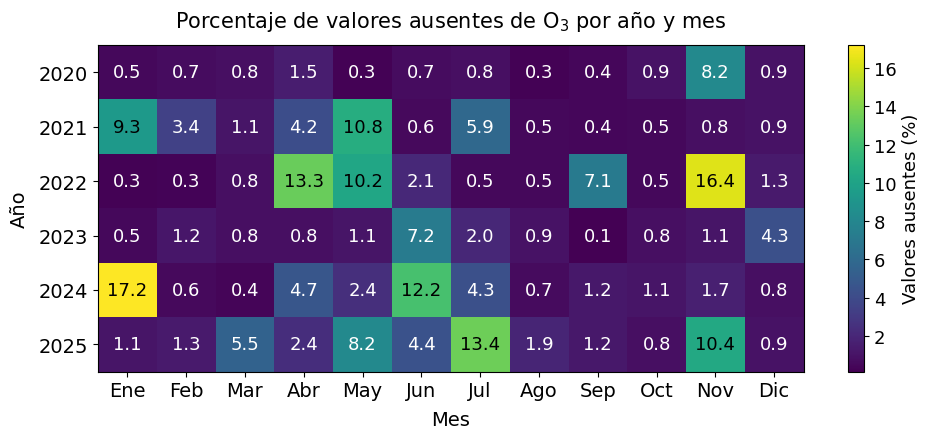

In [54]:
from matplotlib import patheffects as pe

missing_by_year_month = (
    eda_df.groupby(["year", "month"])
    .agg(
        hourly_records=("timestamp", "size"),
        missing_o3_percentage=("o3", lambda values: values.isna().mean() * 100),
    )
    .reset_index()
)

missing_matrix = (
    missing_by_year_month
    .pivot(index="year", columns="month", values="missing_o3_percentage")
    .reindex(index=sorted(eda_df["year"].unique()), columns=range(1, 13))
)

missing_matrix.columns = [MONTH_LABELS[month] for month in missing_matrix.columns]

display(missing_matrix.round(2))

fig, ax = plt.subplots(figsize=(10, 4.5))

cmap = plt.get_cmap("viridis")
norm = plt.Normalize(
    vmin=np.nanmin(missing_matrix.values),
    vmax=np.nanmax(missing_matrix.values),
)

image = ax.imshow(
    missing_matrix.values,
    aspect="auto",
    cmap=cmap,
    norm=norm,
)

ax.set_title(r"Porcentaje de valores ausentes de $\mathrm{O}_3$ por año y mes", fontsize = 15, pad = 13)
ax.set_xlabel("Mes", fontsize = 14, labelpad = 7)
ax.set_ylabel("Año", fontsize = 14, labelpad = 7)

ax.set_xticks(np.arange(missing_matrix.shape[1]))
ax.set_xticklabels(missing_matrix.columns)

ax.set_yticks(np.arange(missing_matrix.shape[0]))
ax.set_yticklabels(missing_matrix.index)

ax.tick_params(axis="both", labelsize=14)

for row_idx in range(missing_matrix.shape[0]):
    for col_idx in range(missing_matrix.shape[1]):
        value = missing_matrix.iat[row_idx, col_idx]

        if pd.isna(value):
            continue

        normalized_value = image.norm(value)
        text_color = "white" if normalized_value < 0.5 else "black"

        ax.text(
            col_idx,
            row_idx,
            f"{value:.1f}",
            ha="center",
            va="center",
            fontsize=13,
            color=text_color,
        )

colorbar = fig.colorbar(image, ax=ax)
colorbar.set_label("Valores ausentes (%)", fontsize = 13)
colorbar.ax.tick_params(labelsize=13)

fig.tight_layout()

save_final_figure(fig, "fig_eda_02_missingness_year_month.png")

plt.show()

## Figura 3 - Distribución global de O3

Esta figura muestra la distribución global de las concentraciones horarias observadas de O3.

Se añaden líneas de referencia para la mediana, el percentil 95 y el percentil 99.

Periodo figura 03: 2020-01-01 00:00:00 → 2024-12-31 23:00:00
Observaciones usadas: 42,561
Mediana: 45.0
p95: 83.0
p99: 97.0
Máximo: 141.0
Figura guardada en: c:\trabajo_github\reports\figures\final\fig_eda_03_o3_distribution.png


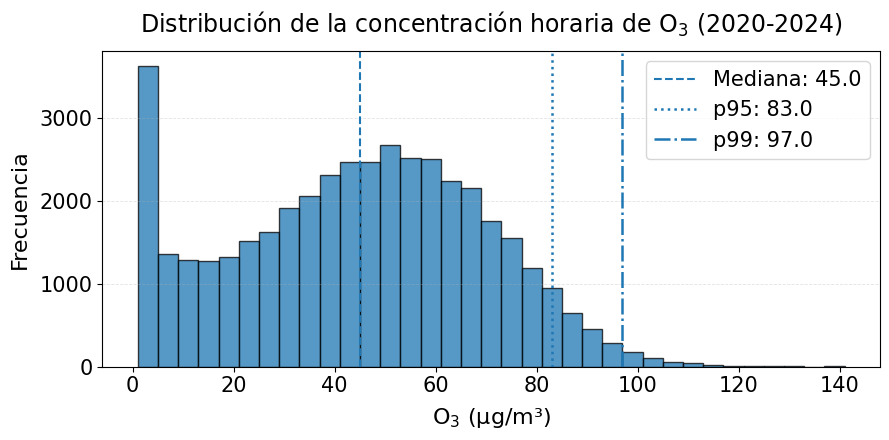

In [53]:
observed_o3 = observed_modeling_df["o3"].dropna()

median_o3 = observed_o3.median()
p95_o3 = observed_o3.quantile(0.95)
p99_o3 = observed_o3.quantile(0.99)

print(
    "Periodo figura 03:",
    observed_modeling_df["timestamp"].min(),
    "→",
    observed_modeling_df["timestamp"].max(),
)
print(f"Observaciones usadas: {len(observed_o3):,}")
print(f"Mediana: {median_o3:.1f}")
print(f"p95: {p95_o3:.1f}")
print(f"p99: {p99_o3:.1f}")
print(f"Máximo: {observed_o3.max():.1f}")

assert observed_modeling_df["timestamp"].max() <= MODELING_END

fig, ax = plt.subplots(figsize=(9, 4.5))

ax.hist(
    observed_o3,
    bins=35,
    edgecolor="black",
    alpha=0.75,
)

ax.axvline(median_o3, linestyle="--", linewidth=1.5, label=f"Mediana: {median_o3:.1f}")
ax.axvline(p95_o3, linestyle=":", linewidth=1.8, label=f"p95: {p95_o3:.1f}")
ax.axvline(p99_o3, linestyle="-.", linewidth=1.8, label=f"p99: {p99_o3:.1f}")

ax.set_title(r"Distribución de la concentración horaria de $\mathrm{O}_3$ (2020-2024)", fontsize = 17, pad = 13)
ax.set_xlabel(r"$\mathrm{O}_3$ (µg/m³)", fontsize = 16, labelpad = 7)
ax.set_ylabel("Frecuencia", fontsize = 16, labelpad = 7)
ax.legend(fontsize=15,
    title_fontsize=13)

ax.tick_params(axis="both", labelsize=15)

ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.35)

fig.tight_layout()

save_final_figure(fig, "fig_eda_03_o3_distribution.png")

plt.show()


## Figura 4 - Estacionalidad mensual, semanal y horaria

Esta figura, de carácter compuesto, resume la estacionalidad mensual, semanal y horaria de la serie temporal de O3.

Periodo figura 04: 2020-01-01 00:00:00 → 2024-12-31 23:00:00
Observaciones usadas en figura 04: 42,561
Máximo de O3 usado en figura 04: 141.0
Figura guardada en: c:\trabajo_github\reports\figures\final\fig_eda_04_seasonality_boxplots.png


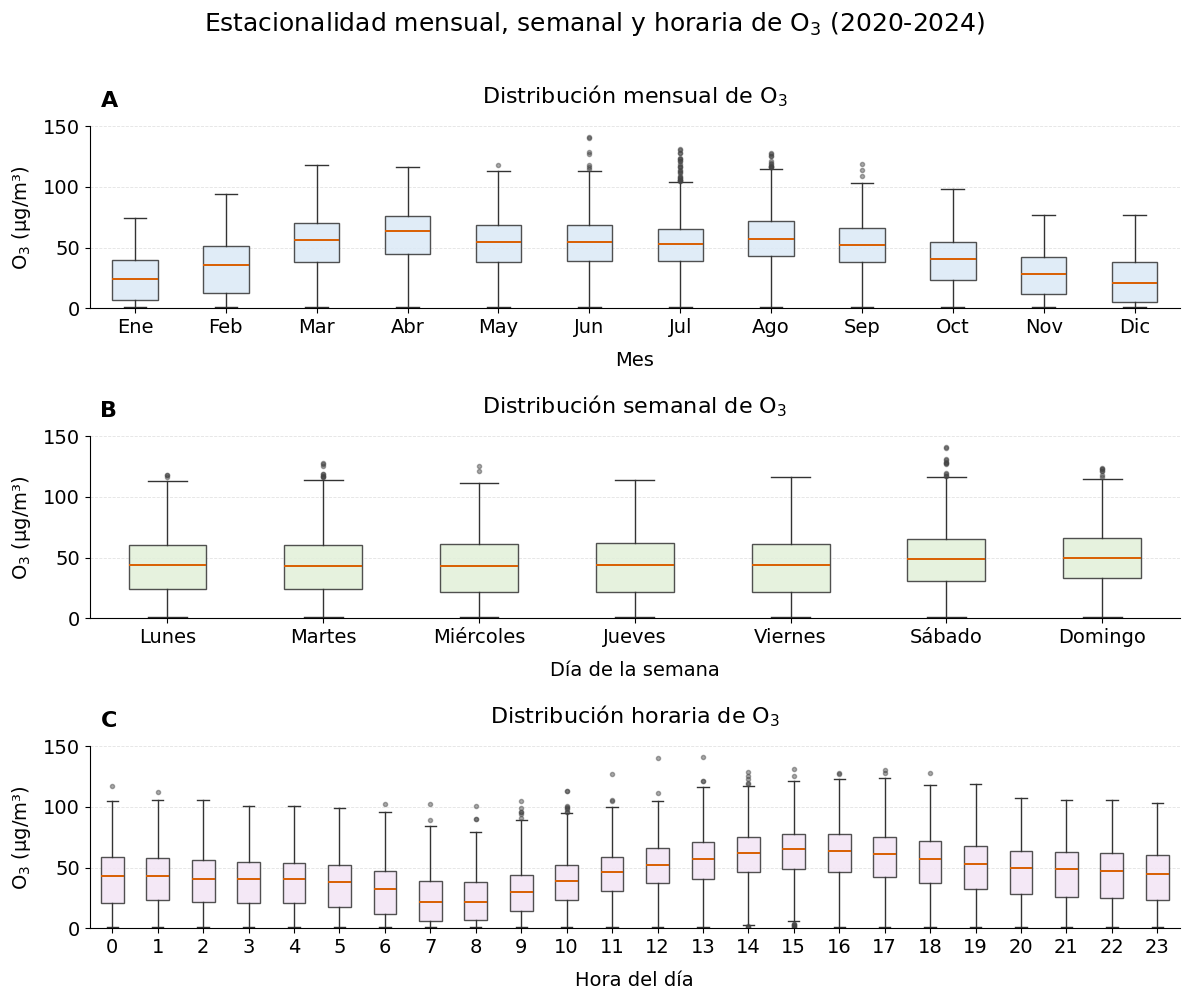

In [62]:
seasonality_df = observed_modeling_df.copy()

print(
    "Periodo figura 04:",
    seasonality_df["timestamp"].min(),
    "→",
    seasonality_df["timestamp"].max(),
)
print(f"Observaciones usadas en figura 04: {len(seasonality_df):,}")
print(f"Máximo de O3 usado en figura 04: {seasonality_df['o3'].max():.1f}")

assert seasonality_df["timestamp"].max() <= MODELING_END
assert seasonality_df["timestamp"].dt.year.max() <= 2024

monthly_boxplot_data = [
    seasonality_df.loc[seasonality_df["month"] == month, "o3"].dropna().to_numpy()
    for month in range(1, 13)
]

weekday_boxplot_data = [
    seasonality_df.loc[seasonality_df["day_of_week"] == day, "o3"].dropna().to_numpy()
    for day in range(7)
]

hourly_boxplot_data = [
    seasonality_df.loc[seasonality_df["hour"] == hour, "o3"].dropna().to_numpy()
    for hour in range(24)
]

def add_outer_panel_label(ax: plt.Axes, label: str) -> None:
    ax.text(
        0.01,
        1.19,
        label,
        transform=ax.transAxes,
        fontsize=16,
        fontweight="bold",
        va="top",
        ha="left",
    )

def draw_styled_boxplot(
    ax: plt.Axes,
    data: list[np.ndarray],
    labels: list[str],
    title: str,
    xlabel: str,
    facecolor: str,
) -> None:
    ax.boxplot(
        data,
        tick_labels=labels,
        showfliers=True,
        patch_artist=True,
        boxprops={
            "facecolor": facecolor,
            "edgecolor": "#333333",
            "linewidth": 1.0,
            "alpha": 0.85,
        },
        medianprops={
            "color": "#d95f02",
            "linewidth": 1.4,
        },
        whiskerprops={
            "color": "#333333",
            "linewidth": 1.0,
        },
        capprops={
            "color": "#333333",
            "linewidth": 1.0,
        },
        flierprops={
            "marker": "o",
            "markersize": 3,
            "markerfacecolor": "#444444",
            "markeredgecolor": "#444444",
            "alpha": 0.45,
        },
    )

    ax.set_title(title, fontsize = 16, pad = 16)
    ax.set_xlabel(xlabel, fontsize = 14, labelpad = 10)
    ax.set_ylabel(r"$\mathrm{O}_3$ (µg/m³)", fontsize = 14, labelpad = 7)
    ax.tick_params(axis="both", labelsize = 14)
    ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.35)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharey=True)

max_o3 = seasonality_df["o3"].max()
upper_y = np.ceil(max_o3 * 1.05 / 10) * 10
upper_y = max(upper_y, 120)

# Panel A: Estacionalidad mensual.
draw_styled_boxplot(
    ax=axes[0],
    data=monthly_boxplot_data,
    labels=[MONTH_LABELS[month] for month in range(1, 13)],
    title=r"Distribución mensual de $\mathrm{O}_3$",
    xlabel="Mes",
    facecolor="#dbe9f6",
)
add_outer_panel_label(axes[0], "A")

# Panel B: Estacionalidad semanal.
draw_styled_boxplot(
    ax=axes[1],
    data=weekday_boxplot_data,
    labels=WEEKDAY_LABELS,
    title=r"Distribución semanal de $\mathrm{O}_3$",
    xlabel="Día de la semana",
    facecolor="#e2f0d9",
)
add_outer_panel_label(axes[1], "B")

# Panel C: Estacionalidad horaria.
draw_styled_boxplot(
    ax=axes[2],
    data=hourly_boxplot_data,
    labels=[str(hour) for hour in range(24)],
    title=r"Distribución horaria de $\mathrm{O}_3$",
    xlabel="Hora del día",
    facecolor="#f3e5f5",
)
add_outer_panel_label(axes[2], "C")

for ax in axes:
    ax.set_ylim(0, upper_y)

fig.suptitle(r"Estacionalidad mensual, semanal y horaria de $\mathrm{O}_3$ (2020-2024)", y=0.995, fontsize = 18)

fig.tight_layout(rect=(0, 0, 1, 0.98))
fig.subplots_adjust(hspace=0.7)

save_final_figure(fig, "fig_eda_04_seasonality_boxplots.png")

plt.show()


## Figura 5 - Percentil 90 de O3 por mes y hora

Esta figura muestra cómo interactúan el ciclo anual y el ciclo diario del ozono troposférico cuando se dan altas concentraciones de este.

Se usa el periodo previo al conjunto de prueba para evitar que el año 2025 influya en decisiones respecto al modelado.

hour,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
Ene,52.0,54.0,54.3,54.9,56.6,52.4,50.0,44.0,37.5,43.0,46.0,46.6,50.8,53.7,57.0,58.0,54.5,51.4,47.8,46.4,46.8,49.4,51.6,50.4
Feb,59.0,60.0,58.0,62.0,60.0,58.0,51.0,45.0,39.0,43.1,52.0,59.5,62.0,67.2,72.3,73.0,76.0,73.0,62.0,60.0,58.0,57.0,55.9,54.9
Mar,79.0,80.0,80.6,78.6,79.2,77.6,69.6,62.6,60.2,64.6,70.9,76.0,80.4,85.0,89.0,88.0,89.4,86.2,83.6,81.2,80.0,79.0,77.6,76.0
Abr,81.0,82.0,80.4,80.8,76.0,74.0,69.9,66.0,61.0,68.0,71.0,74.0,88.0,94.2,96.0,100.0,100.0,99.4,97.0,92.0,86.0,86.7,85.7,85.0
May,73.2,71.0,67.3,67.0,65.0,64.0,60.0,52.0,54.0,61.0,66.8,77.0,79.0,82.8,88.0,93.3,91.0,89.4,85.2,85.0,80.0,77.2,78.0,75.3
Jun,74.0,71.7,71.0,66.7,66.7,61.0,56.7,54.0,58.7,61.0,69.6,76.0,82.0,88.0,88.0,93.7,88.7,89.0,85.5,83.5,80.0,77.5,76.6,76.0
Jul,67.0,66.0,65.0,61.0,59.9,59.0,53.8,50.0,53.0,60.0,68.6,76.0,82.0,89.5,89.4,89.1,87.0,87.8,84.8,77.0,73.0,72.8,71.0,70.9
Ago,75.0,74.6,72.0,71.6,68.6,67.0,61.4,55.2,59.0,67.8,74.1,81.0,88.0,92.0,96.8,97.7,95.0,92.6,88.6,85.0,79.0,79.6,80.0,78.0
Sep,70.3,70.3,68.0,66.0,63.0,60.3,55.0,50.3,49.3,54.2,64.6,71.0,76.0,83.0,85.4,90.0,89.3,87.3,84.0,77.0,73.0,72.0,73.3,72.0
Oct,60.0,60.6,60.1,60.0,60.6,56.2,54.8,46.6,42.2,42.7,52.0,58.0,65.1,69.0,73.0,79.0,79.7,74.6,68.6,65.6,63.0,62.0,62.6,60.0


Figura guardada en: c:\trabajo_github\reports\figures\final\fig_eda_05_month_hour_p90_heatmap.png


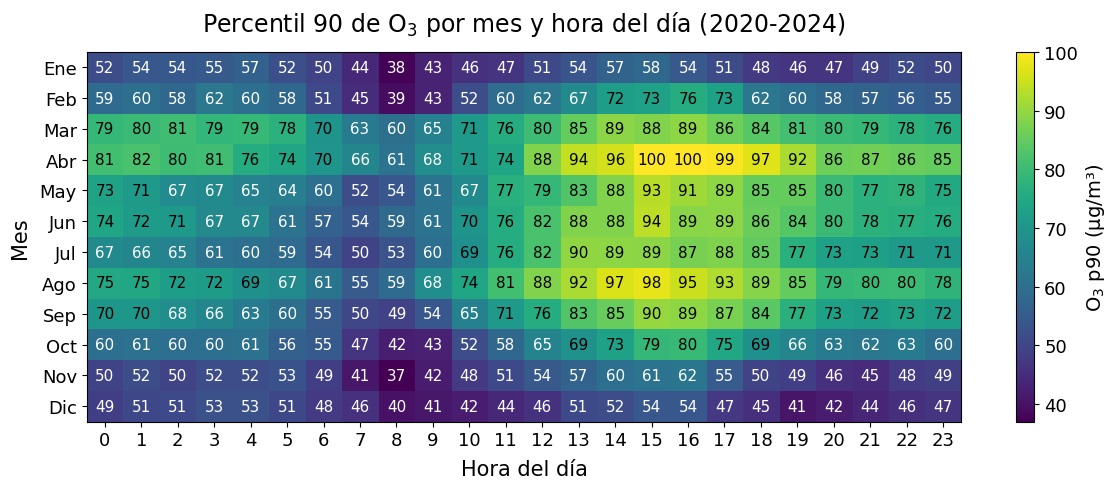

In [76]:
month_hour_p90 = (
    observed_modeling_df
    .pivot_table(
        index="month",
        columns="hour",
        values="o3",
        aggfunc=lambda values: values.quantile(0.90),
    )
    .reindex(index=range(1, 13), columns=range(24))
)

month_hour_p90.index = [MONTH_LABELS[month] for month in month_hour_p90.index]

display(month_hour_p90.round(2))

fig, ax = plt.subplots(figsize=(12, 5))

image = ax.imshow(month_hour_p90.values, aspect="auto")

ax.set_title(r"Percentil 90 de $\mathrm{O}_3$ por mes y hora del día (2020-2024)", fontsize = 17, pad = 15)
ax.set_xlabel("Hora del día", fontsize = 15, labelpad = 7)
ax.set_ylabel("Mes", fontsize = 15, labelpad = 7)

ax.set_xticks(np.arange(24))
ax.set_xticklabels(range(24), fontsize = 13)

ax.set_yticks(np.arange(12))
ax.set_yticklabels(month_hour_p90.index, fontsize = 13)

for row_idx in range(month_hour_p90.shape[0]):
    for col_idx in range(month_hour_p90.shape[1]):
        value = month_hour_p90.iat[row_idx, col_idx]

        if pd.isna(value):
            continue

        normalized_value = image.norm(value)
        text_color = "white" if normalized_value < 0.5 else "black"

        ax.text(
            col_idx,
            row_idx,
            f"{value:.0f}",
            ha="center",
            va="center",
            fontsize=10.9,
            color=text_color,
        )

colorbar = fig.colorbar(image, ax=ax)
colorbar.set_label(r"$\mathrm{O}_3$ p90 (µg/m³)", fontsize = 14)
colorbar.ax.tick_params(labelsize=13)

fig.tight_layout()

save_final_figure(fig, "fig_eda_05_month_hour_p90_heatmap.png")

plt.show()


## Figura 6 - Autocorrelación de O3 para retardos de hasta 168 horas (7 días)

Esta figura muestra hasta qué punto cada valor horario de O3 se parece a valores observados anteriormente, desde 1 hora hasta 168 horas antes.

El retardo de 24 horas permite analizar la repetición diaria; por su parte, el retardo de 168 horas permite observar una posible repetición semanal.

Autocorrelación con lag 1h: 0.9252
Autocorrelación con lag 24h: 0.6340
Autocorrelación con lag 48h: 0.5502
Autocorrelación con lag 168h: 0.5246
Figura guardada en: c:\trabajo_github\reports\figures\final\fig_eda_06_acf_lags.png


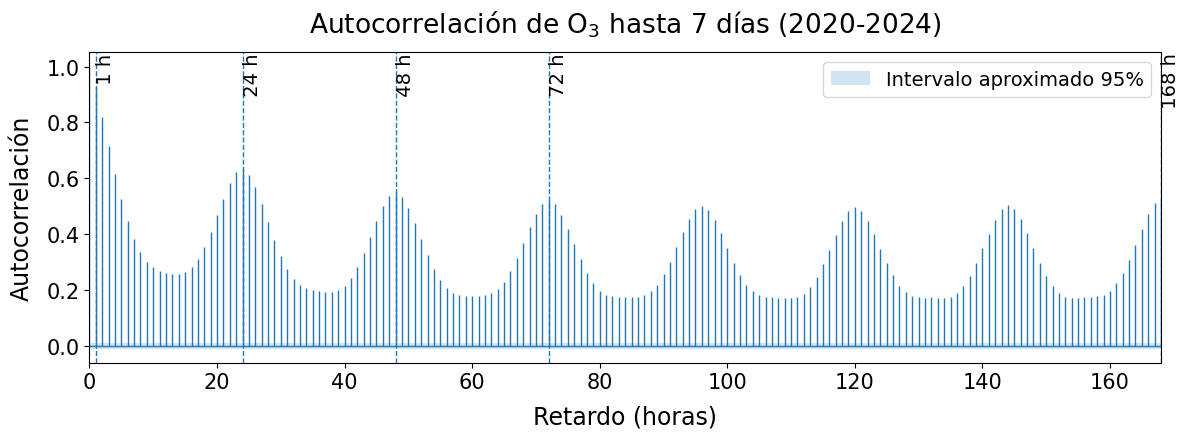

In [104]:
# A continuación, se observará la correlación del O3 actual con sus valores en horas anteriores.
# Para calcular esta correlación correctamente, la serie deberá tener una observación en cada hora;
# como hay algunos valores de O3 ausentes, se rellenarán temporalmente, pero solo para efectuar este análisis.
o3_series_for_acf = (
    eda_modeling_df.set_index("timestamp")["o3"]
    .sort_index()
    .asfreq("h")
    .interpolate(limit_direction="both")
)

assert o3_series_for_acf.index.max() <= MODELING_END

# Se calcula la autocorrelación hasta 7 días atrás.
max_lag = 24 * 7
acf_values = acf(o3_series_for_acf, nlags=max_lag, fft=True)

lags = np.arange(len(acf_values))
confidence_band = 1.96 / np.sqrt(len(o3_series_for_acf))

print(f"Autocorrelación con lag 1h: {acf_values[1]:.4f}")
print(f"Autocorrelación con lag 24h: {acf_values[24]:.4f}")
print(f"Autocorrelación con lag 48h: {acf_values[48]:.4f}")
print(f"Autocorrelación con lag 168h: {acf_values[168]:.4f}")

fig, ax = plt.subplots(figsize=(12, 4.5))

ax.vlines(lags, 0, acf_values, linewidth=1)
ax.axhline(0, linewidth=1)
ax.axhspan(-confidence_band, confidence_band, alpha=0.20, label="Intervalo aproximado 95%")

for selected_lag in [1, 24, 48, 72, 168]:
    ax.axvline(selected_lag, linestyle="--", linewidth=1)
    ax.text(
        selected_lag,
        ax.get_ylim()[1],
        f" {selected_lag} h",
        rotation=90,
        va="top",
        ha="left",
        fontsize = 14,
    )

ax.set_title(r"Autocorrelación de $\mathrm{O}_3$ hasta 7 días (2020-2024)", fontsize = 19, pad = 14)
ax.set_xlabel("Retardo (horas)", fontsize = 17, labelpad = 9)
ax.set_ylabel("Autocorrelación", fontsize = 17, labelpad = 9)
ax.set_xlim(0, max_lag)
ax.legend(loc="upper right", fontsize = 14)

ax.tick_params(labelsize=15)

fig.tight_layout()

save_final_figure(fig, "fig_eda_06_acf_lags.png")

plt.show()


## Figura 7 - Correlogramas de la serie diferenciada

Esta figura muestra la ACF y la PACF de los cambios de O3 respecto a la misma hora del día anterior (`lag_24`).

El objetivo es analizar la dependencia temporal que permanece tras reducirse el ciclo diario dominante. Esta información, además, complementa la autocorrelación de la serie original y contribuye a justificar la selección de retardos para la posterior fase de ingeniería de características.

Autocorrelación con lag 1h tras diferencia diaria: 0.8411
Figura guardada en: c:\trabajo_github\reports\figures\final\fig_eda_07_diff24_correlograms.png


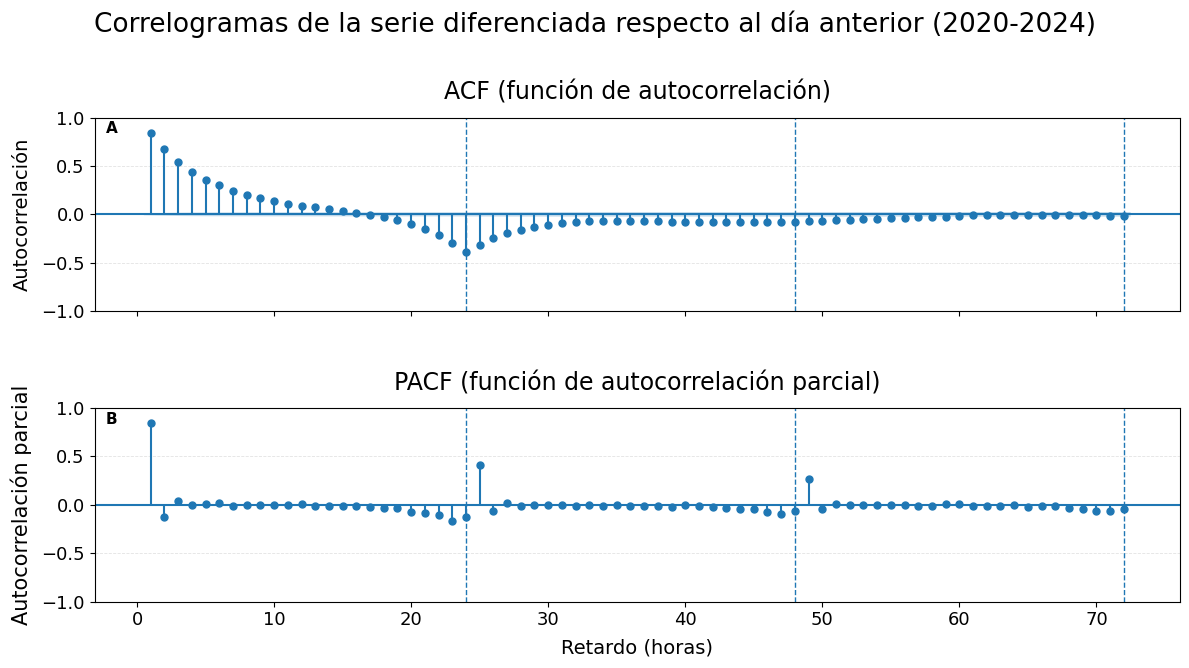

In [97]:
stationarity_series = (
    eda_modeling_df.set_index("timestamp")["o3"]
    .sort_index()
    .asfreq("h")
    .interpolate(limit_direction="both")
)

assert stationarity_series.index.max() <= MODELING_END

# Para los correlogramas se utiliza la serie diferenciada respecto a la misma hora
# del día anterior. Esta transformación reduce el ciclo diario dominante y permite
# observar qué estructura temporal permanece después de eliminar parte de la estacionalidad.
correlogram_series = stationarity_series.diff(24).dropna()

max_lag = 72
acf_diff24_values = acf(correlogram_series, nlags=max_lag, fft=True)

print(f"Autocorrelación con lag 1h tras diferencia diaria: {acf_diff24_values[1]:.4f}")

fig, axes = plt.subplots(2, 1, figsize=(12, 6.5), sharex=True)

plot_acf(
    correlogram_series,
    lags=max_lag,
    ax=axes[0],
    zero=False,
)

for lag in [24, 48, 72]:
    axes[0].axvline(lag, linestyle="--", linewidth=1)

axes[0].set_title("ACF (función de autocorrelación)", fontsize = 17, pad = 13)
axes[0].set_ylabel("Autocorrelación", fontsize = 14, labelpad = 7)
axes[0].grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.35)
add_panel_label(axes[0], "A")

axes[0].tick_params(labelsize=13)

plot_pacf(
    correlogram_series,
    lags=max_lag,
    ax=axes[1],
    zero=False,
    method="ywm",
)

for lag in [24, 48, 72]:
    axes[1].axvline(lag, linestyle="--", linewidth=1)

axes[1].set_title("PACF (función de autocorrelación parcial)", fontsize = 17, pad = 13)
axes[1].set_xlabel("Retardo (horas)", fontsize = 14, labelpad = 7)
axes[1].set_ylabel("Autocorrelación parcial", fontsize = 15, labelpad = 7)
axes[1].grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.35)
add_panel_label(axes[1], "B")

axes[1].tick_params(labelsize=13)

fig.suptitle("Correlogramas de la serie diferenciada respecto al día anterior (2020-2024)", y=1.02, fontsize = 19)

fig.tight_layout()
fig.subplots_adjust(hspace=0.5)

save_final_figure(fig, "fig_eda_07_diff24_correlograms.png")

plt.show()


## Figura 8 - Comparación interanual de perfiles de O3

Esta figura compara, de manera superpuesta, la evolución anual suavizada de la serie para cada año del periodo 2020-2024.

El objetivo es comprobar si el perfil de 2020, pese al contexto de la ZBE y la COVID-19, queda aislado de los años utilizados para el entrenamiento, la calibración y la validación.


,year,date,daily_mean_o3,day_of_year,rolling_14d_mean_o3
0,2020,2020-01-01,13.708333,1,12.732143
1,2020,2020-01-02,11.291667,2,11.906250
2,2020,2020-01-03,10.625000,3,12.333333
3,2020,2020-01-04,11.041667,4,11.991667
4,2020,2020-01-05,14.666667,5,12.734848


Figura guardada en: c:\trabajo_github\reports\figures\final\fig_eda_08_interannual_overlay.png


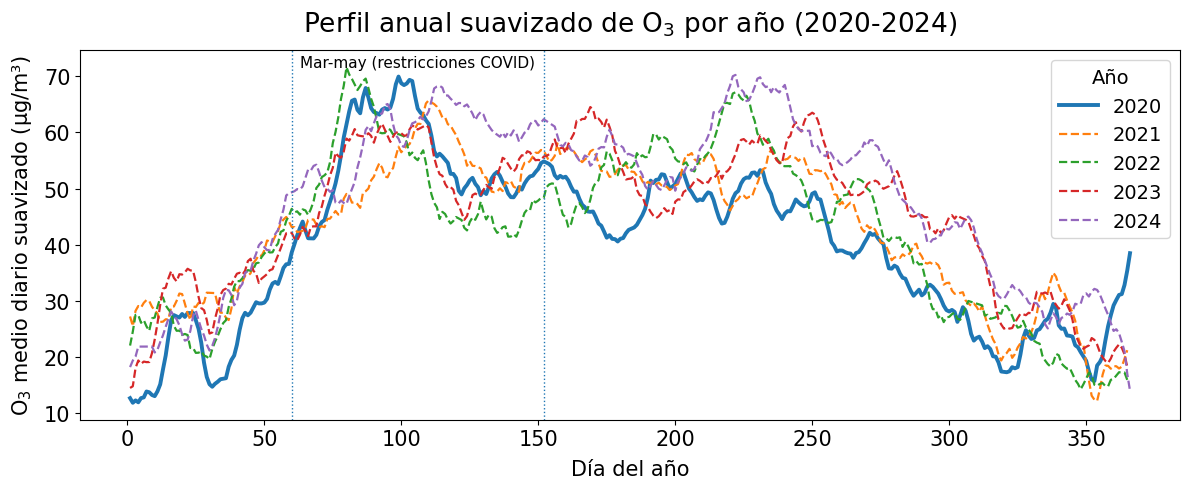

In [105]:
regime_df = (
    eda_modeling_df[eda_modeling_df["year"].between(2020, 2024)]
    .dropna(subset=["o3"])
    .copy()
)

daily_profile_by_year = (
    regime_df.groupby(["year", "date"])
    .agg(daily_mean_o3=("o3", "mean"))
    .reset_index()
)

daily_profile_by_year["day_of_year"] = daily_profile_by_year["date"].dt.dayofyear

daily_profile_by_year["rolling_14d_mean_o3"] = (
    daily_profile_by_year
    .groupby("year")["daily_mean_o3"]
    .transform(lambda values: values.rolling(window=14, center=True, min_periods=5).mean())
)

comparison_years = sorted(daily_profile_by_year["year"].unique())

display(daily_profile_by_year.head())

fig, ax = plt.subplots(figsize=(12, 5))

for year in comparison_years:
    year_data = daily_profile_by_year[daily_profile_by_year["year"] == year]

    linewidth = 2.8 if year == 2020 else 1.6
    linestyle = "-" if year == 2020 else "--"

    ax.plot(
        year_data["day_of_year"],
        year_data["rolling_14d_mean_o3"],
        linewidth=linewidth,
        linestyle=linestyle,
        label=str(year),
    )

# Las líneas verticales delimitan el periodo marzo-mayo,
# asociado a las restricciones más severas por COVID-19 en el año 2020.
ax.axvline(60, linestyle=":", linewidth=1)
ax.axvline(152, linestyle=":", linewidth=1)

upper_y = ax.get_ylim()[1]

ax.text(
    63,
    upper_y * 0.989,
    "Mar-may (restricciones COVID)",
    va="top",
    ha="left",
    fontsize=11,
)

ax.set_title(r"Perfil anual suavizado de $\mathrm{O}_3$ por año (2020-2024)", fontsize = 19, pad = 14)
ax.set_xlabel("Día del año", fontsize = 15, labelpad = 7)
ax.set_ylabel(r"$\mathrm{O}_3$ medio diario suavizado (µg/m³)", fontsize = 15, labelpad = 7)
ax.legend(title="Año", fontsize = 14, title_fontsize = 14)
ax.tick_params(labelsize = 15)

fig.tight_layout()

save_final_figure(fig, "fig_eda_08_interannual_overlay.png")

plt.show()


## Catálogo de figuras definitivas

La siguiente tabla contiene un resumen de las figuras generadas y el mensaje principal que se espera trasladar en la memoria.


In [15]:
final_figures_catalog = pd.DataFrame(
    [
        {
            "figure_id": "EDA-01",
            "filename": "fig_eda_01_temporal_overview.png",
            "title": "Evolución temporal de O3 y partición cronológica",
            "conclusion": "La serie presenta variabilidad horaria, estructura estacional y diferencias entre bloques cronológicos.",
        },
        {
            "figure_id": "EDA-02",
            "filename": "fig_eda_02_missingness_year_month.png",
            "title": "Valores ausentes de O3 por año y mes",
            "conclusion": "Los valores ausentes son moderados, pero no se distribuyen de forma completamente uniforme en el tiempo.",
        },
        {
            "figure_id": "EDA-03",
            "filename": "fig_eda_03_o3_distribution.png",
            "title": "Distribución de la concentración horaria de O3",
            "conclusion": "La distribución presenta muchos valores bajos, un cuerpo central amplio y una cola derecha asociada a episodios elevados.",
        },
        {
            "figure_id": "EDA-04",
            "filename": "fig_eda_04_seasonality_boxplots.png",
            "title": "Estacionalidad mensual, semanal y horaria",
            "conclusion": "La serie presenta patrones mensuales y horarios claros, y un patrón semanal más suave.",
        },
        {
            "figure_id": "EDA-05",
            "filename": "fig_eda_05_month_hour_p90_heatmap.png",
            "title": "Percentil 90 de O3 por mes y hora",
            "conclusion": "Se muestra la importancia que la combinación entre mes y hora del día tiene a la hora de predecir una concentración elevada de O3.",
        },
        {
            "figure_id": "EDA-06",
            "filename": "fig_eda_06_acf_lags.png",
            "title": "Autocorrelación de O3 para retardos de hasta 168 horas",
            "conclusion": "La autocorrelación justifica la utilización de retardos recientes y diarios; el retardo semanal puede valorarse como candidato adicional.",
        },
        {
            "figure_id": "EDA-07",
            "filename": "fig_eda_07_diff24_correlograms.png",
            "title": "Correlogramas de la serie diferenciada respecto al día anterior",
            "conclusion": "La ACF de la serie diferenciada muestra autocorrelación elevada para el retardo de 1 hora; la PACF, además, en los retardos próximos a múltiplos de 24 horas.",
        },
        {
            "figure_id": "EDA-08",
            "filename": "fig_eda_08_interannual_overlay.png",
            "title": "Comparación interanual de los perfiles anuales de O3",
            "conclusion": "El perfil de 2020 no queda aislado respecto al resto de años, lo que apuntala la inclusión de 2020 en el conjunto de entrenamiento.",
        },
    ]
)

display(final_figures_catalog)

final_figures_catalog.to_csv(
    TABLES_DIR / "eda_final_figures_catalog.csv",
    index=False,
    lineterminator="\n",
)

print(f"Catálogo guardado en: {TABLES_DIR / 'eda_final_figures_catalog.csv'}")


,figure_id,filename,title,conclusion
0,EDA-01,fig_eda_01_temporal_overview.png,Evolución temporal de O3 y partición cronológica,"La serie presenta variabilidad horaria, estruc..."
1,EDA-02,fig_eda_02_missingness_year_month.png,Valores ausentes de O3 por año y mes,"Los valores ausentes son moderados, pero no se..."
2,EDA-03,fig_eda_03_o3_distribution.png,Distribución de la concentración horaria de O3,"La distribución presenta muchos valores bajos,..."
3,EDA-04,fig_eda_04_seasonality_boxplots.png,"Estacionalidad mensual, semanal y horaria",La serie presenta patrones mensuales y horario...
4,EDA-05,fig_eda_05_month_hour_p90_heatmap.png,Percentil 90 de O3 por mes y hora,Se muestra la importancia que la combinación e...
5,EDA-06,fig_eda_06_acf_lags.png,Autocorrelación de O3 para retardos de hasta 1...,La autocorrelación justifica la utilización de...
6,EDA-07,fig_eda_07_diff24_correlograms.png,Correlogramas de la serie diferenciada respect...,La ACF de la serie diferenciada muestra autoco...
7,EDA-08,fig_eda_08_interannual_overlay.png,Comparación interanual de los perfiles anuales...,El perfil de 2020 no queda aislado respecto al...


Catálogo guardado en: c:\trabajo_github\reports\tables\eda_final_figures_catalog.csv


In [16]:
# Comprobación final: se verifica que todas las figuras esperadas se han generado.
expected_final_figures = final_figures_catalog["filename"].tolist()

missing_final_figures = [
    filename for filename in expected_final_figures
    if not (FIGURES_FINAL_DIR / filename).exists()
]

if missing_final_figures:
    raise FileNotFoundError(
        "Faltan figuras esperadas: "
        f"{missing_final_figures}"
    )

print("Todas las figuras esperadas se han generado correctamente.")

Todas las figuras esperadas se han generado correctamente.
